In [14]:
import ast
import numpy as np

SEGMENT_INDEX = {
    "spleen": 1,
    "kidney_right": 2,
    "kidney_left": 3,
    "gallbladder": 4,
    "liver": 5,
    "stomach": 6,
    "pancreas": 7,
    "adrenal_gland_right": 8,
    "adrenal_gland_left": 9,
    "lung_upper_lobe_left": 10,
    "lung_lower_lobe_left": 11,
    "lung_upper_lobe_right": 12,
    "lung_middle_lobe_right": 13,
    "lung_lower_lobe_right": 14,
    "esophagus": 15,
    "trachea": 16,
    "thyroid_gland": 17,
    "small_bowel": 18,
    "duodenum": 19,
    "colon": 20,
    "urinary_bladder": 21,
    "prostate": 22,
    "kidney_cyst_left": 23,
    "kidney_cyst_right": 24,
    "sacrum": 25,
    "vertebrae_S1": 26,
    "vertebrae_L5": 27,
    "vertebrae_L4": 28,
    "vertebrae_L3": 29,
    "vertebrae_L2": 30,
    "vertebrae_L1": 31,
    "vertebrae_T12": 32,
    "vertebrae_T11": 33,
    "vertebrae_T10": 34,
    "vertebrae_T9": 35,
    "vertebrae_T8": 36,
    "vertebrae_T7": 37,
    "vertebrae_T6": 38,
    "vertebrae_T5": 39,
    "vertebrae_T4": 40,
    "vertebrae_T3": 41,
    "vertebrae_T2": 42,
    "vertebrae_T1": 43,
    "vertebrae_C7": 44,
    "vertebrae_C6": 45,
    "vertebrae_C5": 46,
    "vertebrae_C4": 47,
    "vertebrae_C3": 48,
    "vertebrae_C2": 49,
    "vertebrae_C1": 50,
    "heart": 51,
    "aorta": 52,
    "pulmonary_vein": 53,
    "brachiocephalic_trunk": 54,
    "subclavian_artery_right": 55,
    "subclavian_artery_left": 56,
    "common_carotid_artery_right": 57,
    "common_carotid_artery_left": 58,
    "brachiocephalic_vein_left": 59,
    "brachiocephalic_vein_right": 60,
    "atrial_appendage_left": 61,
    "superior_vena_cava": 62,
    "inferior_vena_cava": 63,
    "portal_vein_and_splenic_vein": 64,
    "iliac_artery_left": 65,
    "iliac_artery_right": 66,
    "iliac_vena_left": 67,
    "iliac_vena_right": 68,
    "humerus_left": 69,
    "humerus_right": 70,
    "scapula_left": 71,
    "scapula_right": 72,
    "clavicula_left": 73,
    "clavicula_right": 74,
    "femur_left": 75,
    "femur_right": 76,
    "hip_left": 77,
    "hip_right": 78,
    "spinal_cord": 79,
    "gluteus_maximus_left": 80,
    "gluteus_maximus_right": 81,
    "gluteus_medius_left": 82,
    "gluteus_medius_right": 83,
    "gluteus_minimus_left": 84,
    "gluteus_minimus_right": 85,
    "autochthon_left": 86,
    "autochthon_right": 87,
    "iliopsoas_left": 88,
    "iliopsoas_right": 89,
    "brain": 90,
    "skull": 91,
    "rib_left_1": 92,
    "rib_left_2": 93,
    "rib_left_3": 94,
    "rib_left_4": 95,
    "rib_left_5": 96,
    "rib_left_6": 97,
    "rib_left_7": 98,
    "rib_left_8": 99,
    "rib_left_9": 100,
    "rib_left_10": 101,
    "rib_left_11": 102,
    "rib_left_12": 103,
    "rib_right_1": 104,
    "rib_right_2": 105,
    "rib_right_3": 106,
    "rib_right_4": 107,
    "rib_right_5": 108,
    "rib_right_6": 109,
    "rib_right_7": 110,
    "rib_right_8": 111,
    "rib_right_9": 112,
    "rib_right_10": 113,
    "rib_right_11": 114,
    "rib_right_12": 115,
    "sternum": 116,
    "costal_cartilages": 117,
    "patella": 118,
    "tibia": 119,
    "fibula": 120,
    "tarsal": 121,
    "metatarsal": 122,
    "phalanges_feet": 123,
    "ulna": 124,
    "radius": 125,
    "carpal": 126,
    "metacarpal": 127,
    "phalanges_hand": 128,
}

def load_registration_results(filename):
    """
    Load registration results from text file.

    Returns:
        masks_names,
        dice_before_lists,
        dice_after_lists,
        tre_before_lists,
        tre_after_lists
    """

    def parse_list_line(line):
        parts = line.strip().split(";")
        parsed = []
        for p in parts:
            p = p.strip()

            # try to interpret as python literal (list, float, etc.)
            try:
                parsed.append(ast.literal_eval(p))
            except Exception:
                parsed.append(p)

        return parsed

    with open(filename, "r") as f:
        lines = f.readlines()

    masks_names = parse_list_line(lines[0])
    dice_before_lists = parse_list_line(lines[1])
    dice_after_lists = parse_list_line(lines[2])
    tre_before_lists = parse_list_line(lines[3])
    tre_after_lists = parse_list_line(lines[4])

    return (
        masks_names,
        dice_before_lists,
        dice_after_lists,
        tre_before_lists,
        tre_after_lists,
    )



def compute_organ_metric_means(
    masks_names,
    dice_before_lists,
    dice_after_lists,
    tre_before_lists,
    tre_after_lists,
    segment_index_dict
):
    """
    Compute per-organ mean metrics and return them ordered
    according to SEGMENT_INDEX.
    """

    # Compute means first (aligned with masks_names)
    dice_mean_before = [
        float(np.mean(np.asarray(d, dtype=float)))
        for d in dice_before_lists
    ]

    dice_mean_after = [
        float(np.mean(np.asarray(d, dtype=float)))
        for d in dice_after_lists
    ]

    tre_mean_before = [
        float(np.mean(np.asarray(d, dtype=float)))
        for d in tre_before_lists
    ]

    tre_mean_after = [
        float(np.mean(np.asarray(d, dtype=float)))
        for d in tre_after_lists
    ]

    # Pack everything together
    organ_data = []
    for i, organ in enumerate(masks_names):
        if organ in segment_index_dict:  # only keep valid organs
            organ_data.append((
                segment_index_dict[organ],  # index for sorting
                organ,
                dice_mean_before[i],
                dice_mean_after[i],
                tre_mean_before[i],
                tre_mean_after[i]
            ))

    # Sort by SEGMENT_INDEX value
    organ_data.sort(key=lambda x: x[0])

    # Unpack sorted data
    sorted_organs = [x[1] for x in organ_data]
    sorted_dice_before = [x[2] for x in organ_data]
    sorted_dice_after = [x[3] for x in organ_data]
    sorted_tre_before = [x[4] for x in organ_data]
    sorted_tre_after = [x[5] for x in organ_data]

    return (
        sorted_organs,
        sorted_dice_before,
        sorted_dice_after,
        sorted_tre_before,
        sorted_tre_after
    )

# selected_organs = [
#     "brain",
#     "skull",
#     "thyroid_gland",
#     "heart",
#     "aorta",
#     "lung_upper_lobe_left",   # single lung representation
#     "trachea",
#     "esophagus",
#     "liver",
#     "spleen",
#     "pancreas",
#     "stomach",
#     "kidney_left",
#     "kidney_right",
#     "colon",
#     "urinary_bladder",
#     "prostate",
#     "spinal_cord",
#     "vertebrae_L3",
#     "inferior_vena_cava"
# ]
selected_organs = [
    "brain",
    "skull",
    "lung_upper_lobe_left",
    "liver",
    "hip_left",
    "prostate",
    "vertebrae_L3"

]
# selected_organs = [
#     # Skull
#     "skull",

#     # Cervical landmark
#     "vertebrae_C1",   # atlas
#     "vertebrae_C2",   # axis

#     # Thoracic reference
#     "vertebrae_T12",

#     # Lumbar reference
#     "vertebrae_L3",
#     "vertebrae_L5",

#     # Sacral region
#     "sacrum",

#     # Thoracic cage
#     "sternum",
#     "rib_left_1",
#     "rib_right_1",

#     # Shoulder girdle
#     "clavicula_left",
#     "clavicula_right",
#     "scapula_left",
#     "scapula_right",

#     # Upper limb long bone
#     "humerus_left",

#     # Pelvis
#     "hip_left",
#     "hip_right",

#     # Lower limb long bones
#     "femur_left",
#     "femur_right",
#     "tibia"
# ]

In [15]:
import matplotlib.pyplot as plt
import numpy as np

i_values = [4000, 4500, 5000, 5500, 6000, 6500, 7000, 8000]

organ_names = None
dice_improvements = {}
tre_improvements = {}

for i in i_values:

    s = i
    gamma = 2.0
    margin = 3000

    ctsmoothness_proposed = fr"C:\Users\Sam\Downloads\pet_reg_results\ctsmoothness_l{s}_k10_mar{margin}_gam{gamma}.txt"
    ctsmoothness_baseline = fr"C:\Users\Sam\Downloads\pet_reg_results\baseline_l{s}_k10.txt"


    masks_names, _, dice_proposed, _, tre_proposed = \
        load_registration_results(ctsmoothness_proposed)

    masks_names, _, dice_baseline, _, tre_baseline = \
        load_registration_results(ctsmoothness_baseline)

    m, db, da, tb, ta = compute_organ_metric_means(
        selected_organs,
        dice_baseline,
        dice_proposed,
        tre_baseline,
        tre_proposed,
        SEGMENT_INDEX
    )

    # Compute improvements
    d = [x - y for x, y in zip(da, db)]
    t = [x - y for x, y in zip(ta, tb)]

    if organ_names is None:
        organ_names = m
        for organ in organ_names:
            dice_improvements[organ] = []
            tre_improvements[organ] = []

    for organ, d_val, t_val in zip(m, d, t):
        dice_improvements[organ].append(d_val)
        tre_improvements[organ].append(t_val)

print(dice_improvements)

{'liver': [0.01037851723515909, 0.026521833458712174, 0.04440392415287653, 0.027326573450433267, 0.03208378601363171, -0.030411484062033534, 0.017288927289600353, 0.04282871862252863], 'lung_upper_lobe_left': [-0.06308684218674898, 0.01653137393295767, 0.032908965926617295, 0.08989993911236516, 0.04723278274759646, -0.08071934143081305, -0.03179701659828427, 0.005014617368578889], 'prostate': [0.06036032922565937, -0.010824303701519988, 0.011820008791983194, 0.01751978099346152, 0.024461700767278716, -0.02167710606008777, 0.010450956597924277, 0.008117257803678446], 'vertebrae_L3': [-0.0361173510318622, 0.05022066202946007, 0.021722497860901024, 0.07479356317780911, 0.029035364883020554, -0.03697458012029531, 0.08075381097919199, 0.024600803246721648], 'hip_left': [0.05284906104207032, 0.09323288574814792, 0.06102991700172422, 0.0170993290841579, 0.10299008116126063, -0.023485975712537743, 0.06387215331196783, 0.046163272485136964], 'brain': [-0.054204195830971025, 0.03753125071525576,

C:\Users\Sam\AppData\Local\Temp\ipykernel_29256\4165739344.py:20: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(


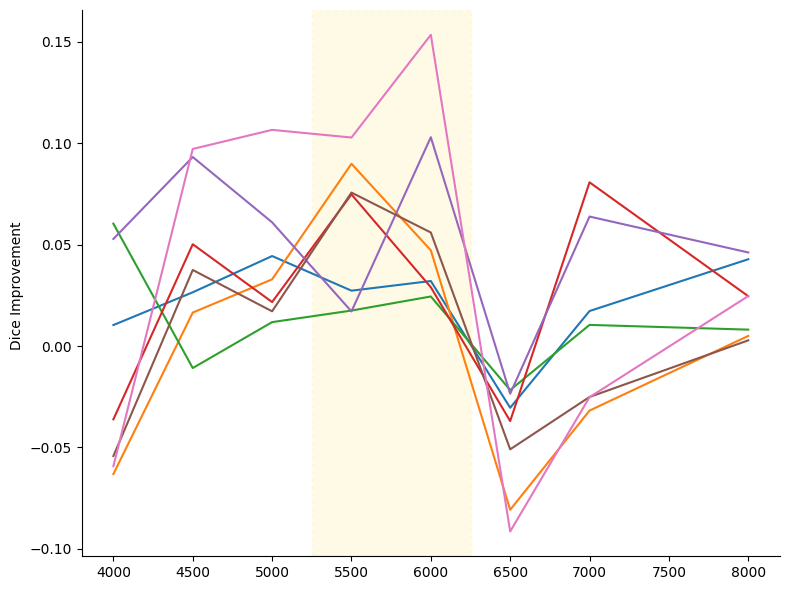

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))

lines = []

for organ in organ_names:
    line, = ax.plot(i_values,
                    dice_improvements[organ],
                    )
    lines.append(line)

# ax.set_xlabel("l value")
ax.set_ylabel("Dice Improvement ")
# ax.set_title("Dice Improvement vs l")
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


x_m, x_ma = 5250, 6250
ax.axvspan(
    x_m, x_ma, 
    color='gold',      # Fill color
    alpha=0.1,           # Transparency (0.1 might be too faint for yellow)
    label='Target Range',
    linestyle=':',       # Dotted line style
    linewidth=2,         # Make the dots thicker
    edgecolor='gold'     # A slightly darker yellow makes the dots "pop"
)



plt.tight_layout()
plt.show()

C:\Users\Sam\AppData\Local\Temp\ipykernel_29256\2918886185.py:20: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(


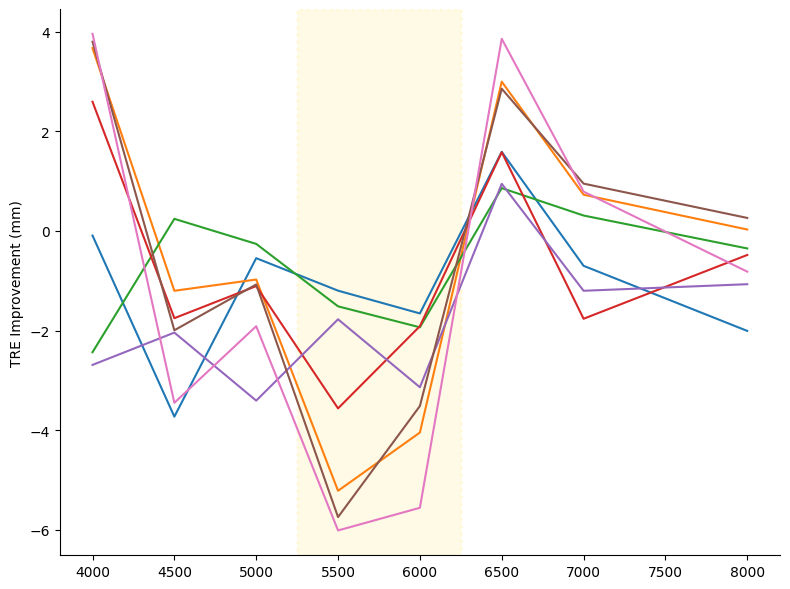

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))

lines = []

for organ in organ_names:
    line, = ax.plot(i_values,
                    tre_improvements[organ],
                    )
    lines.append(line)

# ax.set_xlabel("l value")
ax.set_ylabel("TRE Improvement (mm)")
# ax.set_title("TRE Improvement vs l")
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add a red vertical span (alpha makes it transparent)

ax.axvspan(
    x_m, x_ma, 
    color='gold',      # Fill color
    alpha=0.1,           # Transparency (0.1 might be too faint for yellow)
    label='Target Range',
    linestyle=':',       # Dotted line style
    linewidth=2,         # Make the dots thicker
    edgecolor='gold'     # A slightly darker yellow makes the dots "pop"
)

plt.tight_layout()
plt.show()

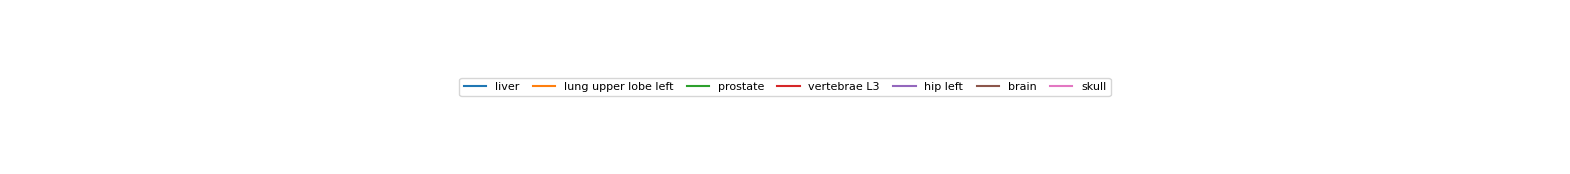

In [18]:
fig_leg, ax_leg = plt.subplots(figsize=(20, 2))  # wide and short
ax_leg.axis('off')

organ_names = [name.replace("_", " ") for name in organ_names]

ax_leg.legend(
    handles=lines,
    labels=organ_names,
    loc='center',
    ncol=len(organ_names),   # all entries in one row
    fontsize=8,
    frameon=True,
    handlelength=2,
    columnspacing=1.2
)

plt.show()

In [19]:
for i in [4000, 4500, 5000, 5500, 6000, 6500, 7000]:


    s = i
    margin = 3000
    # plot_organ_metrics_single_row(masks_names, dice_after_lists, tre_after_lists, selected_organs)
    ctsmoothness_l12000_k10_mar3000_gam1 = fr"C:\Users\Sam\Downloads\pet_reg_results\ctsmoothness_l{s}_k10_mar{margin}_gam1.0.txt"
    ctsmoothness_l12000_k10_mar3000_gam2 = fr"C:\Users\Sam\Downloads\pet_reg_results\ctsmoothness_l{s}_k10_mar{margin}_gam2.0.txt"
    baseline_l12000_k10 = fr"C:\Users\Sam\Downloads\pet_reg_results\baseline_l{s}_k10.txt"

    masks_names, dice_before_lists, dice_after_lists_0, tre_before_lists, tre_after_lists_0 = load_registration_results(ctsmoothness_l12000_k10_mar3000_gam1)
    _, dice_before_lists, dice_after_lists_1, tre_before_lists, tre_after_lists_1 = load_registration_results(ctsmoothness_l12000_k10_mar3000_gam2)
    _, dice_before_lists, dice_after_lists_2, tre_before_lists, tre_after_lists_2 = load_registration_results(baseline_l12000_k10)

    m, db, da, tb, ta = compute_organ_metric_means(selected_organs, dice_before_lists, dice_after_lists_0, tre_before_lists, tre_after_lists_0, SEGMENT_INDEX)

    d = [x - y for x, y in zip(da, db)]
    t = [x - y for x, y in zip(ta, tb)]

    print(m, d, t)

['liver', 'lung_upper_lobe_left', 'prostate', 'vertebrae_L3', 'hip_left', 'brain', 'skull'] [0.033482003616003175, 0.14606463713571433, 0.07049316465854649, 0.11915092220862294, 0.07953741662204272, 0.17876067165943932, 0.1549286718887743] [-2.348417663574219, -6.446652399003506, -3.5285328030586243, -4.8579592689871784, -6.844785222411156, -7.110515087842941, -6.828096505999564]
['liver', 'lung_upper_lobe_left', 'prostate', 'vertebrae_L3', 'hip_left', 'brain', 'skull'] [0.00016842219926110902, 0.07376236333511771, 0.05519605129957206, 0.03926146148570714, 0.05843501724302769, 0.07455821481726266, 0.04981094671529712] [-0.20830158293247258, -1.5667898625135432, -2.0580330371856697, -0.9392607092857368, -4.239890484511852, -1.968308191001416, -2.4199206721037623]
['liver', 'lung_upper_lobe_left', 'prostate', 'vertebrae_L3', 'hip_left', 'brain', 'skull'] [0.05678994078709565, 0.1830707387067378, 0.07658837400376795, 0.16953498261847433, 0.08590515367686757, 0.20536268618616405, 0.2077947